# Setups

In [ ]:
import getpass
import os

In [ ]:
!pip install langgraph langchain

In [ ]:
#for the RAG
!pip install faiss-cpu tiktoken pypdf

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 57.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 338.8/338.8 kB 24.1 MB/s eta 0:00:00


In [ ]:
!pip install langchain-chroma langchain-community

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 25.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 38.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 26.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 548.1/548.1 kB 21.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 17.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 49.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 42.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.8/71.8 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.9/170.9 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.3/61.3 k

In [ ]:
!pip install langchain-classic


In [ ]:
pip install -U langchain-core

In [ ]:
pip install sentence-transformers langchain-huggingface

In [ ]:
!pip install langchain_groq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 5.0 MB/s eta 0:00:00


In [ ]:
!pip install langchain_google_genai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.6/67.6 kB 1.9 MB/s eta 0:00:00


# Imports

In [ ]:
# 1. Core LangGraph components for building the workflow
from langgraph.graph import StateGraph, END
from typing import TypedDict, Annotated, Sequence
import operator

# 2. LangChain components for messages and LLM interaction
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage, SystemMessage
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder

# 3. LangChain tools for RAG (if using LangChain's built-in retrieval)
from langchain_classic.chains import create_retrieval_chain
from langchain_core.tools import create_retriever_tool
from langchain.agents import create_agent

from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from langgraph.prebuilt import create_react_agent

# 4. Interaction with the Groq and Gemini for LLMs
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_groq import ChatGroq



/usr/local/lib/python3.12/dist-packages/langgraph/cache/base/__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


# LLMs Used:
1. Llama 3.1 8B for the three expert agents.
2. Gemini Flash 2.5 for the supervisor agent.


In [ ]:
import os
import getpass
# # The LLM stays the same
os.environ["GOOGLE_API_KEY"] = getpass.getpass("Provide your GOOGLE_API_KEY: ")
llm2 = ChatGoogleGenerativeAI(model="gemini-2.5-flash", temperature=0.2)

# Prompt for the Groq Key
os.environ["GROQ_API_KEY"] = getpass.getpass("Provide your GROQ_API_KEY: ")

# Replace your Gemini llm variable with Groq's super-fast Llama 3!
llm1 = ChatGroq(model_name="llama-3.1-8b-instant", temperature=0.2)

# Embeddings for the RAG

In [ ]:
from langchain_huggingface import HuggingFaceEmbeddings
embeddings = HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2") #this model is based on the Sentence-BERT architecture.
#MiniLM takes any string of text and maps it into a 384-dimensional vector space.

# RAG Tools

In [ ]:
def build_rag_tool(doc_link,tool_name, description):
  #1. Loading of the book, returns a list of langchain Document objects
  loader = PyPDFLoader(doc_link)
  pages = loader.load()

  # 2. Split the book into smaller, searchable chunks
  text_splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
  docs = text_splitter.split_documents(pages)

  # 3. Embedding and storing in a Vector Database
  vector_store = FAISS.from_documents(docs, embeddings)

  # 4. Create a retriever (the search engine for the DB)
  retriever= vector_store.as_retriever(search_kwargs={"k": 3}) # Retrieves top 3 most relevant chunks

  # Give the tool a clear name and description so the LLM knows WHEN to use it
  tool = create_retriever_tool(
      retriever,
      name=tool_name,
      description=description)
  return tool, retriever

In [ ]:
# First Book
doc_link="https://drive.google.com/uc?export=download&id=1wjOGtBt2wJ5JNFFChAr9mMerUfYJxbDw"
tool_name="search_nvc_book"
description="Searches and returns excerpts from 'Nonviolent Communication'. Always use this tool to find relevant frameworks (Observations, Feelings, Needs, Requests) before answering."

tool_for_nvc, retriever_nvc= build_rag_tool(doc_link,tool_name, description)
tools_for_nvc = [tool_for_nvc]

In [ ]:
#Second Book
doc_link="https://drive.google.com/uc?export=download&id=1a82NueEBJfp_TSCGAxGCchHpLzNjL-fG"
tool_name="search_7_habits_book"
description="Searches and returns excerpts from 'The 7 Habits of Highly Effective People'. Always use this tool to find relevant principles before answering."

tool_for_7habits, retriever_7habits = build_rag_tool(doc_link, tool_name, description)
tools_for_7habits =[tool_for_7habits]

In [ ]:
#Third Book
doc_link="https://drive.google.com/uc?export=download&id=1NNFBuczVevjZqfa63Eyc74lIOJPtIRny"
tool_name="search_predictably_irrational_book"
description="Searches and returns excerpts from 'Predictably Irrational' by Dan Ariely. Always use this tool to find relevant behavioral economics principles and hidden irrational forces before answering."

tool_for_irrational_coach, retriever_irrational= build_rag_tool(doc_link, tool_name, description)
tools_for_irrational_coach=[tool_for_irrational_coach]

In [ ]:
# SUPERVISOR RAG -> A RAG of the 3 books
from langchain_classic.retrievers import MergerRetriever

all_books_retriever = MergerRetriever(retrievers=[
    retriever_7habits,
    retriever_irrational,
    retriever_nvc])

tool_all_books = create_retriever_tool(
    all_books_retriever,
    name="search_all_books",
    description=(
        "Searches all three books simultaneously: '7 Habits', "
        "'Predictably Irrational', and 'Nonviolent Communication'. "
        "Use this to ground your synthesis in actual book content."))

tools_for_supervisor = [tool_all_books]

# Multi-Agent Architecture Design
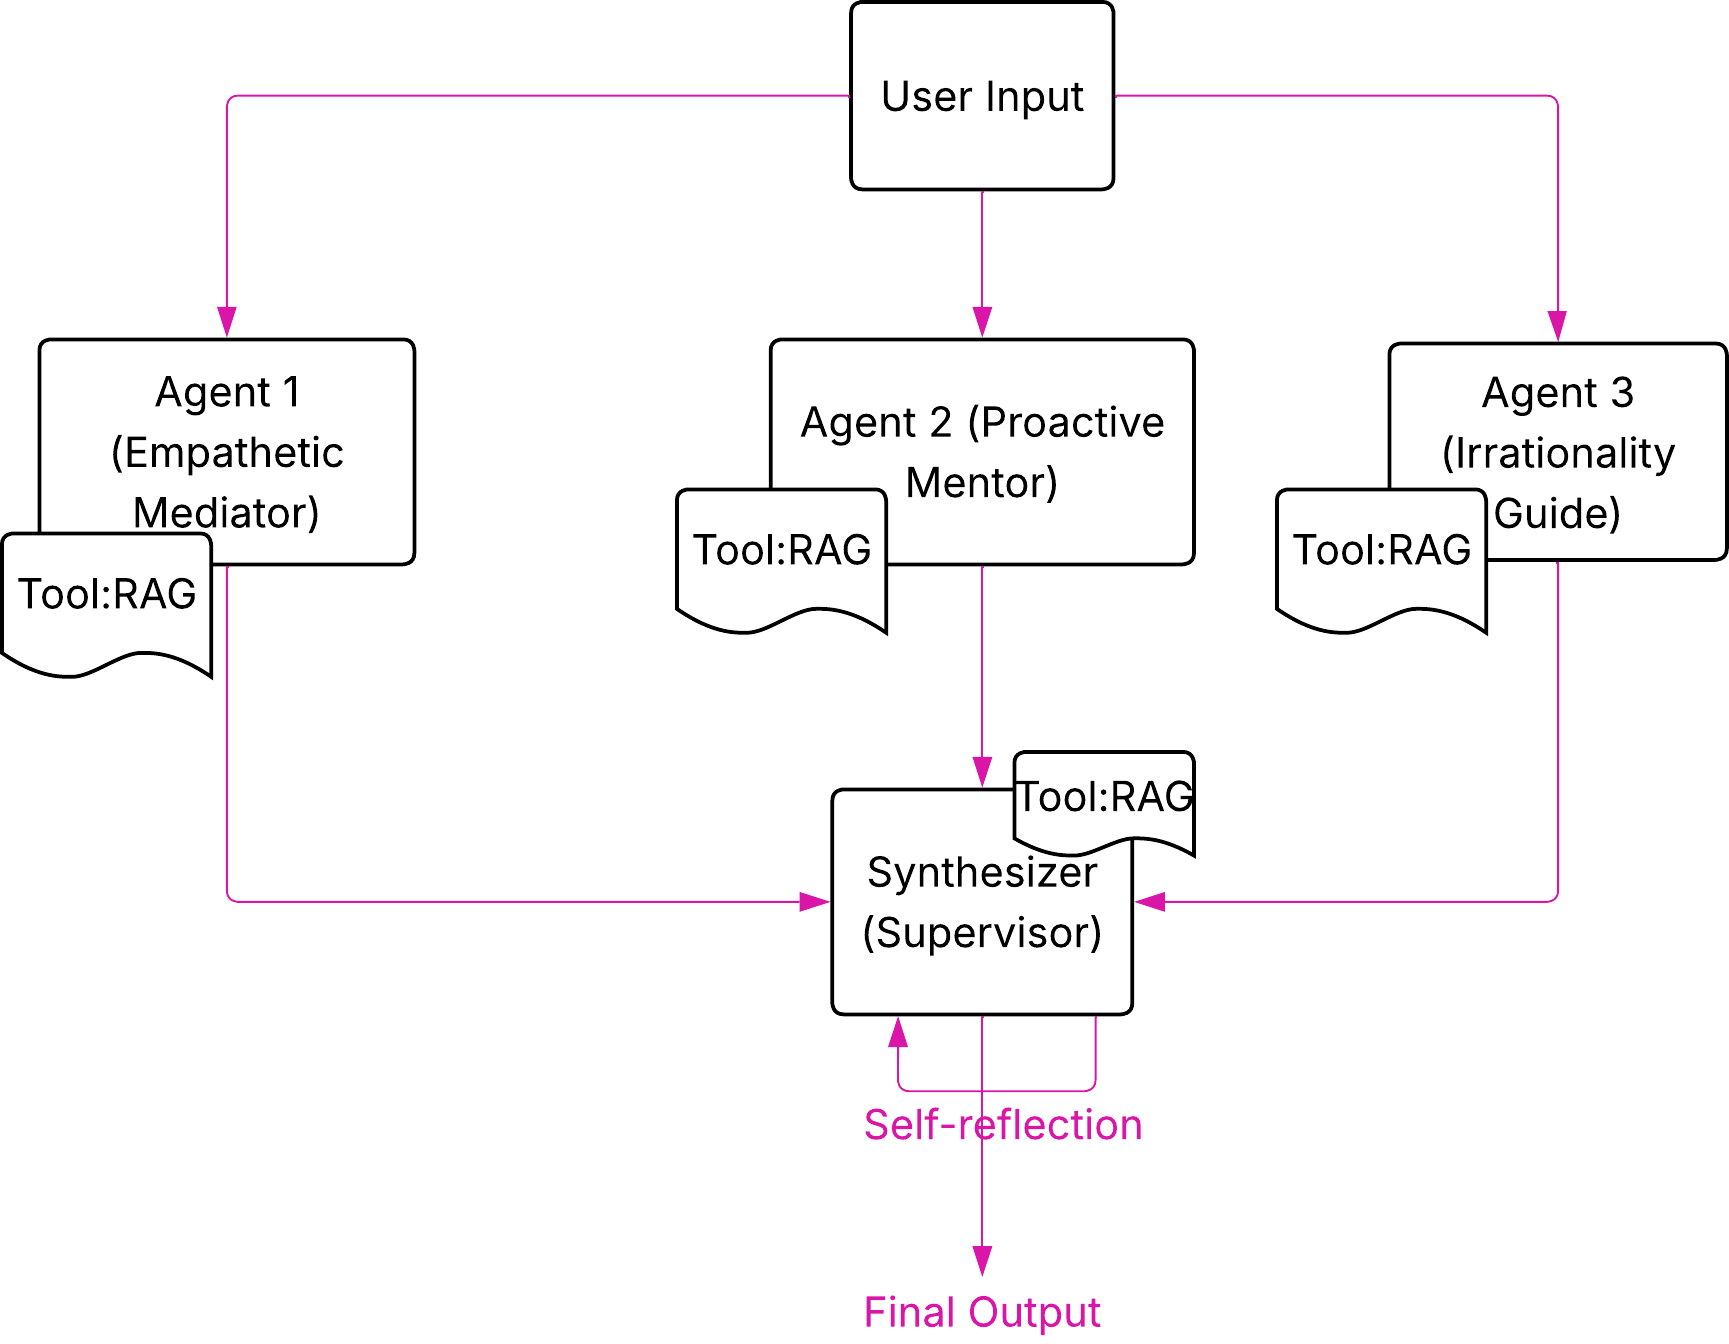

# Three Parallel Agents

In [ ]:
import time
from groq import RateLimitError

def safe_invoke(agent, state, retries=3, wait=40):
    for i in range(retries):
        try:
            return agent.invoke(state)
        except RateLimitError:
            if i < retries - 1:
                print(f"Rate limit hit, waiting {wait}s...")
                time.sleep(wait)
            else:
                raise

In [ ]:
# Agent 1 (Nonviolent Communication)
nvc_sys_prompt = """You are the 'Nonviolent Communication' agent, expert in Marshall Rosenberg's NVC framework.
Analyze the user's situation using EXACTLY this structure:

OBSERVATION: [State only the factual event, no interpretation or blame. What happened objectively?]
FEELINGS: [What emotions is the user likely experiencing? What emotions is the other person likely experiencing?]
UNMET NEEDS: [What core human needs are unmet for each party? e.g. connection, respect, understanding, autonomy]
REQUEST: [One concrete, positive, doable action the user can take or propose right now]

Rules:
- Use the book tool before answering to ground your response in NVC principles.
- Do not moralize or assign blame.
- Keep each section to 2-3 sentences maximum.
- Do not add sections beyond the four above."""

nvc_agent = create_agent(model=llm1, tools=tools_for_nvc, system_prompt=nvc_sys_prompt)

#state contains the entire global memory of the system.
def nvc_node(state):
    result = safe_invoke(nvc_agent, state)
    output = result["messages"][-1].content
    return {
        "messages": result["messages"],
        "agent_outputs": {**state.get("agent_outputs", {}), "NVC": output} #update the state
    }

In [ ]:
# Agent 2 (Rational Coach Agent)
seven_habits_sys_prompt = """You are the 'Rational Coach', an expert in Stephen Covey's 'The 7 Habits of Highly Effective People'.
Your goal is to help the user navigate their situation using principle-centered, logical, and proactive thinking.

When analyzing the user's scenario, apply the following frameworks:
1- CIRCLE OF INFLUENCE: [what the user can control vs. must let go]
2- BE PROACTIVE: [one concrete initiative the user can take]
3- WIN-WIN: [how both parties' needs can be met]
4- SEEK TO UNDERSTAND: [how the user should approach the next conversation]
Tone: Empowering, structured, objective, and highly practical. Focus on long-term effectiveness.
Keep each section to 2-3 sentences. Use the book tool before answering.
Do not just list the habits; apply them directly to the user's specific problem. Provide actionable steps."""
seven_habits_agent = create_agent(model =llm1, tools=tools_for_irrational_coach,system_prompt= seven_habits_sys_prompt)

def seven_habits_node(state):
    result = safe_invoke(seven_habits_agent,state)
    output = result["messages"][-1].content
    return {
        "messages": result["messages"],
        "agent_outputs": {**state.get("agent_outputs", {}), "7Habits": output}
    }


In [ ]:
behavioral_analyst_sys_prompt = """You are the 'Behavioral Analyst', an expert in behavioral economics based on Dan Ariely's 'Predictably Irrational'.
You understand that humans are rarely logical. Your goal is to uncover the hidden, irrational forces shaping the user's situation.

When analyzing the scenario, look for and explain the following cognitive biases or hidden forces:
1- IRRATIONAL FORCE IDENTIFIED: [name the primary bias or norm violation at play]
2- WHY THEY'RE ACTING THIS WAY: [explain the hidden psychological mechanism]
3- THE TRAP TO AVOID: [what mistake the user is about to make because of this bias]
4- HOW TO NAVIGATE IT: [one concrete reframe or action]
Keep each section to 2-3 sentences. Use the book tool before answering.
Tone: Analytical, inquisitive, and slightly skeptical of "rational" explanations.
Your job is to tell the user why people in the scenario are acting irrationally and how to navigate those hidden psychological traps."""

behavioral_analyst_agent = create_agent(model=llm1, tools=tools_for_7habits, system_prompt= behavioral_analyst_sys_prompt)

def behavioral_analyst_node(state):
    result = safe_invoke(behavioral_analyst_agent,state)
    output = result["messages"][-1].content
    return {
        "messages": result["messages"],
        "agent_outputs": {**state.get("agent_outputs", {}), "BehavioralAnalyst": output}
    }


In [ ]:
def retrieval_node(state):
    user_input = state["user_input"]

    # Directly query the merged retriever — no LLM decision involved
    docs = all_books_retriever.invoke(user_input)

    # Format the retrieved passages cleanly
    book_context = "\n\n".join([
        f"[{doc.metadata.get('source', 'Book')}]\n{doc.page_content}"
        for doc in docs
    ])

    return {"book_context": book_context}

# Supervisor

In [ ]:
def merge_dicts(a: dict, b: dict) -> dict:
    return {**a, **b}

class AgentState(TypedDict):
    messages:           Annotated[Sequence[BaseMessage], operator.add]
    user_input:         str
    agent_outputs:      Annotated[dict, merge_dicts]
    book_context:       str
    draft_synthesis:    str
    critique_history:   list  # Store feedback from previous iterations
    is_approved:        bool  # Flag to determine if the draft passes evaluation
    reflection_count:   int

In [ ]:
def extract_content(message):
    """Safely extract string content from a message regardless of format"""
    content = message.content
    if isinstance(content, str):
        return content.strip()
    elif isinstance(content, list):
        # Content is a list of blocks — join the text ones
        return " ".join(
            block.get("text", "") if isinstance(block, dict) else str(block)
            for block in content
        ).strip()
    else:
        return str(content).strip()

In [ ]:
import json

MAX_REFLECTIONS = 3

# 1: THE DRAFTER (Using Tools & History)

drafter_prompt_template = """
PHASE 1 — DRAFT
Read the user prompt carefully to understand their situation and core problem.
Inspect each expert agent's analysis carefully.
Based on the agents' outputs and the retrieved chunks from the three books based on user prompt, write a response that includes:
- A brief, direct acknowledgment of the user's situation (1-2 sentences max, no excessive empathy).
- A clear action plan with concrete steps and examples the user can follow.

Use 'search_all_books' to retrieve any needed info from the three books.

Tone rules:
- Be warm but concise — do not over-validate or repeat the user's feelings back to them more than once.
- Do not use phrases like "It's completely understandable", "I can see why you felt", "You're in a tough spot" — these feel performative.
- Vary your opening. Do not start every response with the exact same empathy phrase. If this is a follow-up in an ongoing chat, skip the filler and get straight to the advice.
- Do not attribute advice to any book by name. No phrases like "As NVC suggests", "The 7 Habits emphasizes", "Predictably Irrational explains".
- The three perspectives must be woven into a single coherent advice, not presented as separate sections per book.
- Write as a single trusted advisor speaking directly to the user, not as a coordinator summarizing experts.

=========================================
USER QUESTION:
{user_input}

EXPERT AGENT OUTPUTS:
{agents_text}

RETRIEVED BOOK PASSAGES (Context):
{book_context}

CRITIQUE HISTORY (Previous attempts and feedback):
{critique_text}
=========================================

IMPORTANT INSTRUCTIONS:
1. If there is a CRITIQUE HISTORY, it means your previous draft was rejected. You MUST address the feedback and fix the mistakes in your new draft.
2. Write ONLY the final response text. Do not add any introductory text.
"""

# Define the Drafter as a React Agent so it can use the retriever tool
supervisor_drafter_agent = create_react_agent(
    model=llm2,
    tools=tools_for_supervisor
)

def supervisor_drafter_node(state):
    user_input = state["user_input"]
    book_context = state.get("book_context", "")

    # Aggregate expert agent outputs
    agent_messages = [m for m in state["messages"] if isinstance(m, AIMessage) and m.name in ["NVC_Agent", "Seven_Habits_Agent", "Behavioral_Analyst_Agent"]]
    agents_text = "\n\n".join([f"=== {m.name} ===\n{m.content}" for m in agent_messages])

    # Prepare the critique history
    critique_history = state.get("critique_history", [])
    critique_text = "\n\n".join(critique_history) if critique_history else "This is your first attempt. No critiques yet."

    formatted_prompt = drafter_prompt_template.format(
        user_input=user_input,
        agents_text=agents_text,
        book_context=book_context,
        critique_text=critique_text
    )

    # Invoke the drafter agent
    agent_result = supervisor_drafter_agent.invoke({
        "messages": [HumanMessage(content=formatted_prompt)]
    })

    draft = extract_content(agent_result["messages"][-1])

    return {"draft_synthesis": draft}

# 2: THE EVALUATOR (Strict JSON Output)

evaluator_prompt_template = """
You are a strict evaluator. Read the user's situation and the proposed draft.
USER QUESTION: {user_input}
DRAFT TO EVALUATE: {draft}

Evaluate the draft against these 5 criteria:
1. Relevance: Directly addresses the situation?
2. Groundedness: Actionable and logically sound based on the context?
3. Integration: Perspectives woven together naturally?
4. Actionability: Contains concrete steps?
5. Tone: Warm but not performative?
6. Tone Variation: Empathy is allowed, but FAIL the Tone criteria if the draft uses repetitive, robotic openings like 'It's understandable' on every turn. It should vary its opening or jump straight to the point in follow-up questions.

You MUST return a valid JSON object with EXACTLY this structure:
{{
    "Relevance_Pass": true or false,
    "Groundedness_Pass": true or false,
    "Integration_Pass": true or false,
    "Actionability_Pass": true or false,
    "Tone_Pass": true or false,
    "Feedback_Notes": "If any criteria is false, provide specific actionable instructions on what to change. If all are true, write 'Perfect'."
}}
Respond with ONLY the JSON object. Do not add markdown blocks like ```json.
"""

def supervisor_evaluator_node(state):
    draft = state.get("draft_synthesis", "")
    user_input = state.get("user_input", "")

    prompt = evaluator_prompt_template.format(user_input=user_input, draft=draft)
    response = llm2.invoke([HumanMessage(content=prompt)])
    content = extract_content(response)

    # Clean JSON markdown if the model includes it
    if content.startswith("```json"):
        content = content.replace("```json", "").replace("```", "").strip()
    elif content.startswith("```"):
        content = content.replace("```", "").strip()

    try:
        evaluation = json.loads(content)
        # The draft passes only if all 5 criteria evaluate to True
        all_passed = all([
            evaluation.get("Relevance_Pass", False),
            evaluation.get("Groundedness_Pass", False),
            evaluation.get("Integration_Pass", False),
            evaluation.get("Actionability_Pass", False),
            evaluation.get("Tone_Pass", False)
        ])
        feedback = evaluation.get("Feedback_Notes", "No feedback provided.")
    except Exception as e:
        all_passed = False
        feedback = "Failed to parse JSON. Please follow the JSON format strictly and rewrite."

    # Increment loop count and append the new feedback to the history
    count = state.get("reflection_count", 0) + 1
    new_history = state.get("critique_history", []) + [f"Attempt {count} Feedback: {feedback}"]

    # # ---------------------------------------------------------
    # # PRINT STATEMENT ADDED HERE TO SEE THE EVALUATION
    # # ---------------------------------------------------------
    # print(f"\n\n{'='*20} ⚖️ EVALUATION STAGE {'='*20}")
    # print(f"RAW JSON OUTPUT:\n{content}")
    # print(f"\nDECISION: {'✅ APPROVED (Flow will finish)' if all_passed else '❌ REJECTED (Flow will loop back to Drafter)'}")
    # print("="*60)
    # # ---------------------------------------------------------


    return {
        "reflection_count": count,
        "critique_history": new_history,
        "is_approved": all_passed
    }

# End2End Graph

## Implement

In [ ]:
def parallel_input_node(state):
    return {}

In [ ]:
def evaluation_router(state):
    is_approved = state.get("is_approved", False)
    count = state.get("reflection_count", 0)

    # Stop looping if approved or if the maximum number of reflections is reached
    if is_approved or count >= MAX_REFLECTIONS:
        return "FINISH"
    else:
        return "reflect"

In [ ]:
workflow = StateGraph(AgentState)

workflow.add_node("parallel_input",    parallel_input_node)
workflow.add_node("NVC",               nvc_node)
workflow.add_node("7Habits",           seven_habits_node)
workflow.add_node("BehavioralAnalyst", behavioral_analyst_node)
workflow.add_node("retrieval",         retrieval_node)

# Add the new Supervisor Drafter and Evaluator nodes
workflow.add_node("supervisor_drafter",   supervisor_drafter_node)
workflow.add_node("supervisor_evaluator", supervisor_evaluator_node)

workflow.set_entry_point("parallel_input")
workflow.add_edge("parallel_input",    "NVC")
workflow.add_edge("parallel_input",    "7Habits")
workflow.add_edge("parallel_input",    "BehavioralAnalyst")

workflow.add_edge("NVC",               "retrieval")
workflow.add_edge("7Habits",           "retrieval")
workflow.add_edge("BehavioralAnalyst", "retrieval")

# After retrieval, go to the drafter
workflow.add_edge("retrieval", "supervisor_drafter")

# After drafting, go to the evaluator
workflow.add_edge("supervisor_drafter", "supervisor_evaluator")

# Route based on evaluation results
workflow.add_conditional_edges(
    "supervisor_evaluator",
    evaluation_router,
    {
        "reflect": "supervisor_drafter",
        "FINISH": END
    }
)

app = workflow.compile()

## Visualize

In [ ]:
# Compile the graph into a runnable application
from IPython.display import Image, display

try:
    # This generates a visual map of your nodes and edges
    img = Image(app.get_graph().draw_mermaid_png())
    display(img)
except Exception as e:
    print(f"Could not generate graph visualization: {e}")

## Run

In [ ]:
import time
from groq import RateLimitError

# Global conversation history — persists across multiple turns
conversation_history = []

def ask_multiagent(question, retries=3, wait=40):
    global conversation_history

    # Build full context by prepending history to the question
    if conversation_history:
        history_text = "\n".join([
            f"{'User' if msg['role'] == 'user' else 'Assistant'}: {msg['content']}"
            for msg in conversation_history
        ])
        full_question = f"""Previous conversation:\n{history_text}\n\nNow the user says: {question}\n\nPlease consider the full conversation context in your response."""
    else:
        full_question = question

    for i in range(retries):
        try:
            final_state = app.invoke({
                "messages":         [HumanMessage(content=full_question)],
                "user_input":       full_question,
                "agent_outputs":    {},
                "book_context":     "",
                "draft_synthesis":  "",
                "critique_history": [],     # Reset history for a new question
                "is_approved":      False,  # Reset approval status
                "reflection_count": 0
            })

            # Extract the final approved draft
            answer = final_state.get("draft_synthesis", "")

            # Save this turn to history
            conversation_history.append({"role": "user",      "content": question})
            conversation_history.append({"role": "assistant", "content": answer})

            # Extract sources
            sources = []
            book_context = final_state.get("book_context", "")
            if book_context:
                for chunk in book_context.split("\n\n"):
                    if chunk.startswith("["):
                        source_line = chunk.split("\n")[0]
                        if source_line not in sources:
                            sources.append(source_line)

            return answer, sources

        except RateLimitError:
            if i < retries - 1:
                print(f"Rate limit hit, waiting {wait}s...")
                time.sleep(wait)
            else:
                raise

# UI

In [ ]:
from IPython.display import HTML, display, Javascript
from google.colab import output
import re

def format_markdown(text):
    """Convert markdown bold/italic/bullets/numbered lists to HTML"""
    lines = text.split('\n')
    result = []
    in_ul = False  # Unordered list (bullets)
    in_ol = False  # Ordered list (numbered)
    ol_counter = 0

    for line in lines:
        stripped = line.strip()

        # ── Bullet point: * text ──────────────────────────
        if stripped.startswith('* '):
            if in_ol:
                result.append('</ol>')
                in_ol = False
                ol_counter = 0
            if not in_ul:
                result.append('<ul style="margin: 12px 0; padding-left: 22px;">')
                in_ul = True
            content = stripped[2:]
            content = re.sub(r'\*\*(.*?)\*\*', r'<strong>\1</strong>', content)
            result.append(f'<li style="margin-bottom: 8px; line-height: 1.7;">{content}</li>')

        # ── Numbered list: 1. text ────────────────────────
        elif re.match(r'^\d+\.\s+', stripped):
            if in_ul:
                result.append('</ul>')
                in_ul = False
            if not in_ol:
                result.append('<ol style="margin: 12px 0; padding-left: 22px; list-style-type: decimal;">')
                in_ol = True
            content = re.sub(r'^\d+\.\s+', '', stripped)  # Remove original number
            content = re.sub(r'\*\*(.*?)\*\*', r'<strong>\1</strong>', content)
            content = re.sub(r'\*(.*?)\*', r'<em>\1</em>', content)
            result.append(f'<li style="margin-bottom: 8px; line-height: 1.7;">{content}</li>')

        # ── Empty line ────────────────────────────────────
        elif stripped == '':
            if in_ul:
                result.append('</ul>')
                in_ul = False
            if in_ol:
                result.append('</ol>')
                in_ol = False
                ol_counter = 0
            result.append('<br>')

        # ── Regular text ──────────────────────────────────
        else:
            if in_ul:
                result.append('</ul>')
                in_ul = False
            if in_ol:
                result.append('</ol>')
                in_ol = False
                ol_counter = 0
            line = re.sub(r'\*\*(.*?)\*\*', r'<strong>\1</strong>', stripped)
            line = re.sub(r'\*(.*?)\*', r'<em>\1</em>', line)
            result.append(f'<p style="margin: 6px 0; line-height: 1.7;">{line}</p>')

    # Close any open lists at end of text
    if in_ul:
        result.append('</ul>')
    if in_ol:
        result.append('</ol>')

    return '\n'.join(result)

html_interface = """
<div style="font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif; max-width: 900px; margin: 0 auto; background: #f8fafc; border-radius: 16px; overflow: hidden; box-shadow: 0 4px 25px rgba(0,0,0,0.1);">

    <div style="background: linear-gradient(135deg, #4a90a4 0%, #2c6e8a 50%, #1a4f6e 100%);
                padding: 30px; color: white; text-align: center;
                box-shadow: 0 4px 15px rgba(0,0,0,0.15); z-index: 10; position: relative;">
        <div style="font-size: 48px; margin-bottom: 10px;">🧠</div>
        <h1 style="margin: 0; font-size: 28px; font-weight: 700; letter-spacing: 0.5px;">Your Personal Therapist</h1>
        <p style="margin: 10px 0 0 0; opacity: 0.85; font-size: 15px;">
            Powered by NVC · 7 Habits · Behavioral Economics
        </p>
        <div style="display: flex; justify-content: center; gap: 20px; margin-top: 15px; font-size: 13px; opacity: 0.75;">
            <span>💬 Nonviolent Communication</span>
            <span>📈 7 Habits</span>
            <span>🧩 Predictably Irrational</span>
        </div>
    </div>

    <div id="chatHistory" style="height: 500px; overflow-y: auto; padding: 25px; scroll-behavior: smooth;">
        <div id="welcomeMessage" style="text-align: center; padding: 50px 20px; color: #7b8794;
                    background: linear-gradient(135deg, #ffffff 0%, #f0f7fa 100%);
                    border-radius: 12px; border: 2px dashed #b8d8e8;">
            <div style="font-size: 52px; margin-bottom: 15px;">🌿</div>
            <p style="margin: 0; font-size: 17px; font-weight: 600; color: #2c6e8a;">
                A safe space for your thoughts
            </p>
            <p style="margin: 10px 0 0 0; font-size: 14px; opacity: 0.75;">
                Share a situation, a conflict, or a feeling — our AI advisors will guide you
            </p>
            <div style="display: flex; justify-content: center; gap: 15px; margin-top: 20px; flex-wrap: wrap;">
                <span style="background: white; color: #2c6e8a; padding: 6px 14px; border-radius: 20px; font-size: 13px; box-shadow: 0 2px 5px rgba(0,0,0,0.05);">💡 Conflict resolution</span>
                <span style="background: white; color: #2c6e8a; padding: 6px 14px; border-radius: 20px; font-size: 13px; box-shadow: 0 2px 5px rgba(0,0,0,0.05);">❤️ Relationship advice</span>
                <span style="background: white; color: #2c6e8a; padding: 6px 14px; border-radius: 20px; font-size: 13px; box-shadow: 0 2px 5px rgba(0,0,0,0.05);">🎯 Setting boundaries</span>
            </div>
        </div>
    </div>

    <div style="background: white; padding: 20px 25px; border-top: 1px solid #e1e5e9; z-index: 10; position: relative;">
        <div style="display: flex; gap: 12px;">
            <textarea id="questionInput"
                   placeholder="Type your situation here..."
                   style="flex: 1; padding: 15px; border: 2px solid #e1e5e9; border-radius: 12px;
                          font-size: 15px; font-family: inherit; resize: none; height: 60px;
                          transition: all 0.3s ease; line-height: 1.5; background: #f8fafc;"
                   onfocus="this.style.borderColor='#4a90a4'; this.style.background='white';"
                   onblur="this.style.borderColor='#e1e5e9'; this.style.background='#f8fafc';"></textarea>
            <button onclick="askQuestion()"
                    style="background: linear-gradient(135deg, #4a90a4 0%, #2c6e8a 100%);
                           color: white; border: none; padding: 15px 25px; border-radius: 12px;
                           cursor: pointer; font-size: 16px; font-weight: 600; align-self: flex-end;
                           transition: transform 0.2s ease, box-shadow 0.2s ease; white-space: nowrap;"
                    onmouseover="this.style.transform='translateY(-2px)'; this.style.boxShadow='0 4px 12px rgba(44, 110, 138, 0.3)';"
                    onmouseout="this.style.transform='none'; this.style.boxShadow='none';">
                Send 📤
            </button>
        </div>
    </div>
</div>

<script>
function askQuestion() {
    var questionInput = document.getElementById('questionInput');
    var question = questionInput.value;
    if (!question.trim()) {
        return;
    }

    var chatHistory = document.getElementById('chatHistory');

    // Remove welcome message on first use
    var welcome = document.getElementById('welcomeMessage');
    if (welcome) welcome.remove();

    // 1. Append User Message
    var userHtml = `
        <div style="display: flex; justify-content: flex-end; margin-bottom: 20px;">
            <div style="background: #4a90a4; color: white; padding: 15px 20px; border-radius: 18px 18px 0 18px;
                        max-width: 80%; box-shadow: 0 4px 15px rgba(74, 144, 164, 0.2);">
                <p style="margin: 0; font-size: 15px; line-height: 1.5;">${question}</p>
            </div>
        </div>
    `;
    chatHistory.insertAdjacentHTML('beforeend', userHtml);

    // 2. Append Loading Animation
    var loadingHtml = `
        <div id="loadingBubble" style="display: flex; justify-content: flex-start; margin-bottom: 20px;">
            <div style="background: white; padding: 15px 20px; border-radius: 18px 18px 18px 0;
                        border: 1px solid #e1e5e9; display: flex; align-items: center; gap: 15px;">
                <div class="dot-flashing"></div>
                <span style="color: #7b8794; font-size: 14px;">Advisors are analyzing...</span>
            </div>
        </div>
    `;
    chatHistory.insertAdjacentHTML('beforeend', loadingHtml);

    // Scroll to bottom and clear input
    chatHistory.scrollTop = chatHistory.scrollHeight;
    questionInput.value = '';

    // Send to Python function
    google.colab.kernel.invokeFunction('notebook.ask_question', [question], {});
}

// Support hitting 'Enter' to send (Shift+Enter for new line)
document.getElementById("questionInput").addEventListener("keydown", function(event) {
    if (event.key === "Enter" && !event.shiftKey) {
        event.preventDefault();
        askQuestion();
    }
});

var style = document.createElement('style');
style.innerHTML = `
.dot-flashing {
    position: relative; width: 8px; height: 8px; border-radius: 5px;
    background-color: #4a90a4; color: #4a90a4;
    animation: dotFlashing 1s infinite linear alternate; animation-delay: 0.5s;
}
.dot-flashing::before, .dot-flashing::after {
    content: ''; display: inline-block; position: absolute; top: 0;
}
.dot-flashing::before {
    left: -15px; width: 8px; height: 8px; border-radius: 5px;
    background-color: #4a90a4; animation: dotFlashing 1s infinite alternate; animation-delay: 0s;
}
.dot-flashing::after {
    left: 15px; width: 8px; height: 8px; border-radius: 5px;
    background-color: #4a90a4; animation: dotFlashing 1s infinite alternate; animation-delay: 1s;
}
@keyframes dotFlashing {
    0% { opacity: 1; transform: scale(1); }
    50% { opacity: 0.6; transform: scale(0.8); }
    100% { opacity: 0.3; transform: scale(0.6); }
}
`;
document.head.appendChild(style);
</script>
"""

display(HTML(html_interface))

def ask_question(question):
    try:
        answer, sources = ask_multiagent(question)

        formatted_answer = format_markdown(answer)

        sources_html = ""
        if sources:
            source_items = "".join([
                f'<li style="margin-bottom: 4px; color: #4a90a4; font-size: 13px;">{source}</li>'
                for source in sources
            ])
            sources_html = f"""
            <div style="margin-top: 15px; padding-top: 15px; border-top: 1px solid #e1e5e9;">
                <p style="margin: 0 0 8px 0; font-size: 13px; font-weight: 700; color: #2c6e8a;">
                    📚 Referenced Insights:
                </p>
                <ul style="margin: 0; padding-left: 18px;">
                    {source_items}
                </ul>
            </div>
            """

        agent_badges = """
            <div style="display: flex; gap: 6px; flex-wrap: wrap; margin-bottom: 12px;">
                <span style="background: #f0f7fa; color: #2c6e8a; padding: 3px 10px; border-radius: 12px; font-size: 11px; font-weight: 600; border: 1px solid #b8d8e8;">💬 NVC</span>
                <span style="background: #f0f7fa; color: #2c6e8a; padding: 3px 10px; border-radius: 12px; font-size: 11px; font-weight: 600; border: 1px solid #b8d8e8;">📈 7 Habits</span>
                <span style="background: #f0f7fa; color: #2c6e8a; padding: 3px 10px; border-radius: 12px; font-size: 11px; font-weight: 600; border: 1px solid #b8d8e8;">🧩 Behavioral</span>
            </div>
        """

        response_html = f"""
        <div style="display: flex; justify-content: flex-start; margin-bottom: 20px;">
            <div style="background: white; padding: 20px; border-radius: 18px 18px 18px 0;
                        max-width: 85%; box-shadow: 0 4px 15px rgba(0,0,0,0.05); border: 1px solid #e1e5e9;">
                <div style="display: flex; align-items: flex-start; gap: 15px;">
                    <div style="background: linear-gradient(135deg, #4a90a4 0%, #1a4f6e 100%);
                                color: white; width: 35px; height: 35px; border-radius: 50%;
                                display: flex; align-items: center; justify-content: center;
                                flex-shrink: 0; box-shadow: 0 2px 8px rgba(74,144,164,0.3);">
                        <span style="font-size: 18px;">🧠</span>
                    </div>
                    <div style="flex: 1;">
                        {agent_badges}
                        <div style="color: #2d3748; font-size: 15px; line-height: 1.7;">
                            {formatted_answer}
                        </div>
                        {sources_html}
                    </div>
                </div>
            </div>
        </div>
        """

        # Remove loading bubble and append the actual response
        display(Javascript(f"""
            var loading = document.getElementById('loadingBubble');
            if (loading) loading.remove();

            var chatHistory = document.getElementById('chatHistory');
            chatHistory.insertAdjacentHTML('beforeend', `{response_html}`);
            chatHistory.scrollTop = chatHistory.scrollHeight;
        """))

    except Exception as e:
        error_html = f"""
        <div style="display: flex; justify-content: flex-start; margin-bottom: 20px;">
            <div style="background: #fff5f5; padding: 15px 20px; border-radius: 18px 18px 18px 0;
                        border: 1px solid #fed7d7; max-width: 80%;">
                <div style="display: flex; align-items: center; gap: 10px;">
                    <span style="font-size: 18px;">⚠️</span>
                    <div>
                        <p style="margin: 0; color: #c53030; font-weight: 600; font-size: 14px;">Error occurred</p>
                        <p style="margin: 4px 0 0 0; color: #742a2a; font-size: 13px;">{str(e)}</p>
                    </div>
                </div>
            </div>
        </div>
        """
        display(Javascript(f"""
            var loading = document.getElementById('loadingBubble');
            if (loading) loading.remove();

            var chatHistory = document.getElementById('chatHistory');
            chatHistory.insertAdjacentHTML('beforeend', `{error_html}`);
            chatHistory.scrollTop = chatHistory.scrollHeight;
        """))

output.register_callback('notebook.ask_question', ask_question)

In [ ]:
"""I had a huge fight with my close friend, Alex, because they felt I was ignoring them.
I've been incredibly overwhelmed with a major project at work for the past three weeks and barely have time to sleep.
Yesterday, Alex sent me a long text saying, 'You clearly don't care about our friendship anymore since you never make time for me.'

I felt attacked and immediately got defensive. I snapped back, 'I'm trying to survive my job, I'm sorry I don't have endless free time to entertain you! Plus, I paid for our dinner the last time we actually did hang out, so you know I care.'
Alex just replied 'Wow.' and hasn't spoken to me since.

Now I feel terrible, but I'm also still resentful that they aren't being understanding of my stress. I want to fix this, but I don't want to just apologize and pretend my boundaries around work don't matter. What should I do?"""

In [ ]:
"What exactly should I say in the first message to Alex?"
"What if Alex doesn't respond at all?"
"I'm scared they'll get angry again if I reach out"
"Can you write me the actual text message to send?"

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Compare with Baseline LLM

In [ ]:
from langchain_core.messages import SystemMessage, HumanMessage

# 1. The "Mega-Prompt"
# We ask the LLM to try and remember the books from its training data,
# acting as all experts simultaneously.
baseline_sys_prompt = """You are an expert life coach and behavioral advisor.
The user will give you a personal or professional problem.
You must analyze their situation and give them an action plan by combining principles from three specific books:
1. 'Nonviolent Communication' by Marshall Rosenberg (Focus on Observations, Feelings, Needs, Requests).
2. 'The 7 Habits of Highly Effective People' by Stephen Covey (Focus on proactivity, circle of influence, win-win).
3. 'Predictably Irrational' by Dan Ariely (Focus on hidden behavioral forces, social norms, relativity, etc.).

Your output must include:
- A brief, direct acknowledgment of the user's situation (1-2 sentences max, no excessive empathy).
- A clear action plan with concrete steps and examples the user can follow.

Tone rules:
- Be warm but concise — do not over-validate or repeat the user's feelings back to them.
- Do not use phrases like "It's completely understandable".
- The three perspectives must be woven into a single coherent advice, not presented as separate sections per book.
- Write as a single trusted advisor speaking directly to the user.
"""

def run_simple_baseline(user_input, model):
    """
    Runs the user input through a single, simple LLM without RAG or Agents.
    """
    print("==================================================")
    print("RUNNING BASELINE (SIMPLE LLM) ...")
    print("==================================================\n")

    # Package the prompt and user input
    messages = [
        SystemMessage(content=baseline_sys_prompt),
        HumanMessage(content=user_input)
    ]

    # Invoke the model directly
    result = model.invoke(messages)

    print(result.content.strip())
    print("\n==================================================")
    return result.content.strip()

test_prompt = "I had a huge fight with my close friend, Alex, because they felt I was ignoring them. I've been incredibly overwhelmed with a major project at work for the past three weeks and barely have time to sleep. Yesterday, Alex sent me a long text saying, 'You clearly don't care about our friendship anymore since you never make time for me.' I felt attacked and immediately got defensive. I snapped back, 'I'm trying to survive my job, I'm sorry I don't have endless free time to entertain you! Plus, I paid for our dinner the last time we actually did hang out, so you know I care.' Alex just replied 'Wow.' and hasn't spoken to me since. Now I feel terrible, but I'm also still resentful that they aren't being understanding of my stress. I want to fix this, but I don't want to just apologize and pretend my boundaries around work don't matter. What should I do?"
baseline_output = run_simple_baseline(test_prompt, llm2)